In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split


In [2]:
df= pd.read_csv("/content/456Social_Network_Ads.csv")
df
df.dtypes

,0
User ID,int64
Gender,object
Age,int64
EstimatedSalary,int64
Purchased,int64


In [19]:
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [3]:
df.describe()

,User ID,Age,EstimatedSalary,Purchased
count,4.000000e+02,400.000000,400.000000,400.000000
mean,1.569154e+07,37.655000,69742.500000,0.357500
std,7.165832e+04,10.482877,34096.960282,0.479864
min,1.556669e+07,18.000000,15000.000000,0.000000
25%,1.562676e+07,29.750000,43000.000000,0.000000
50%,1.569434e+07,37.000000,70000.000000,0.000000
75%,1.575036e+07,46.000000,88000.000000,1.000000
max,1.581524e+07,60.000000,150000.000000,1.000000


In [4]:
df.isnull().sum()

,0
User ID,0
Gender,0
Age,0
EstimatedSalary,0
Purchased,0


In [29]:
df_encoded = pd.get_dummies(df,columns = ['Gender'], prefix='is')

In [32]:
df_encoded.drop('User ID', axis = 1, inplace = True)

In [33]:
df_encoded.head()

,Age,EstimatedSalary,Purchased,is_Female,is_Male
0,19,19000,0,False,True
1,35,20000,0,False,True
2,26,43000,0,True,False
3,27,57000,0,True,False
4,19,76000,0,False,True


In [34]:
x = df_encoded.drop('Purchased',axis = 1)
Y = df_encoded['Purchased']

In [35]:
x_train,x_test,y_train,y_test = train_test_split(x,Y,test_size=0.20,random_state=0)

In [36]:
x_train

,Age,EstimatedSalary,is_Female,is_Male
336,58,144000,False,True
64,59,83000,True,False
55,24,55000,True,False
106,26,35000,True,False
300,58,38000,True,False
...,...,...,...,...
323,48,30000,True,False
192,29,43000,False,True
117,36,52000,False,True
47,27,54000,True,False


In [37]:
y_train

,Purchased
336,1
64,0
55,0
106,0
300,1
...,...
323,1
192,0
117,0
47,0


In [40]:
classifier=LogisticRegression(max_iter=1000)


In [41]:
classifier.fit(x_train,y_train)

LogisticRegression(max_iter=1000)

In [42]:
y_pred=classifier.predict(x_test)
y_pred

array([0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1])

In [43]:
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
cm=confusion_matrix(y_test,y_pred)
cm


array([[56,  2],
       [ 4, 18]])

In [44]:
tp,fn,fp,tn = confusion_matrix(y_test,y_pred,labels=[1,0]).reshape(-1)
print(tp,fn,fp,tn)

18 4 2 56


In [45]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

print("Accuracy Score:\n",accuracy_score(y_test,y_pred))
print("Classification Report:\n",classification_report(y_test,y_pred))

Accuracy Score:
 0.925
Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.97      0.95        58
           1       0.90      0.82      0.86        22

    accuracy                           0.93        80
   macro avg       0.92      0.89      0.90        80
weighted avg       0.92      0.93      0.92        80



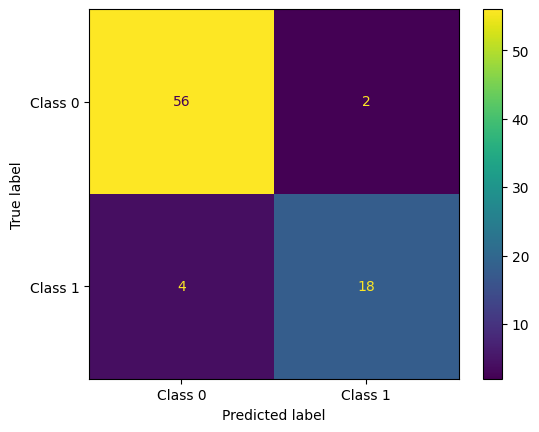

In [47]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Class 0', 'Class 1'])
disp.plot()